In [ ]:
import sys
import subprocess
import importlib.util

In [ ]:
from pathlib import Path
import json


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import mlflow

np.random.seed(42)
tf.random.set_seed(42)

Тут грузим данные, есть в нескольких строках проблемы с чтением, поэтому их если что не будем брать а просто скипнем

In [ ]:
df = pd.read_csv(
    "product_hunt_raw_api_full.csv",
    engine="python",
    on_bad_lines="skip"
)

In [ ]:
df

,edge_cursor,id,name,slug,tagline,description,url,website,createdAt,scheduledAt,...,user_url,user_twitterUsername,user_websiteUrl,user_followersCount,user_followingCount,user_isMaker,user_createdAt,user_madePosts_totalCount,user_submittedPosts_totalCount,user_json
0,MQ,1157655,adyoutiser,adyoutiser,Self-service marketplace for digital out-of-ho...,adyoutiser is the self-service marketplace for...,https://www.producthunt.com/products/adyoutise...,https://www.producthunt.com/r/OL3KCGBBOQTKBF?u...,2026-06-02T07:01:00Z,2026-06-02T07:01:00Z,...,https://www.producthunt.com/@christian_starzen...,NaN,NaN,0,0,True,2025-08-26T08:29:39Z,1,1,"{""id"": ""8913845"", ""name"": ""Christian Starzengr..."
1,Mg,1158104,Knock agent for Slack,knock-agent-for-slack,"Build, manage, and ship customer messaging fro...",Knock is the agent-led customer engagement pla...,https://www.producthunt.com/products/knock-6?u...,https://www.producthunt.com/r/HLPDZ4CZXGT3XJ?u...,2026-06-02T07:01:00Z,2026-06-02T07:01:00Z,...,https://www.producthunt.com/@fmerian?utm_campa...,fmerian,https://www.producthunt.com/upcoming/notion-de...,68696,32,True,2014-07-07T07:52:28Z,8,353,"{""id"": ""25713"", ""name"": ""fmerian"", ""username"":..."
2,Mw,1146535,Co-Invest,co-invest,Trade 500+ markets directly from ChatGPT & Claude,Co-Invest by Liquid lets you research and plac...,https://www.producthunt.com/products/liquid-5?...,https://www.producthunt.com/r/CSYK6KJGP743GJ?u...,2026-06-02T07:01:00Z,2026-06-02T07:01:00Z,...,https://www.producthunt.com/@justin2025?utm_ca...,NaN,NaN,2884,17,True,2024-08-03T05:26:18Z,5,43,"{""id"": ""7419054"", ""name"": ""Justin Jincaid"", ""u..."
3,NaN,1157761,ContractHQ,contracthq,Catch every renewal. Spot every red flag.,Auto-renewals creep up. Contracts pile up in i...,https://www.producthunt.com/products/contracth...,https://www.producthunt.com/r/AMK7DZUEDRBOKX?u...,2026-06-02T07:01:00Z,2026-06-02T07:01:00Z,...,https://www.producthunt.com/@niklas__?utm_camp...,NaN,NaN,5,1,True,2023-02-07T12:02:07Z,3,3,"{""id"": ""5128305"", ""name"": ""Niklas"", ""username""..."
4,NQ,1160889,ForgeSpy,forgespy,"AI detector for any link, photo, video, or voice","ForgeSpy tells you if an image, video, or voic...",https://www.producthunt.com/products/forgespy?...,https://www.producthunt.com/r/L24AAJPP5VYA2T?u...,2026-06-02T07:01:00Z,2026-06-02T07:01:00Z,...,https://www.producthunt.com/@zyur_io?utm_campa...,zyur_io,http://zyur.io,0,0,True,2025-01-16T12:22:51Z,3,3,"{""id"": ""8039894"", ""name"": ""zyur"", ""username"": ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122364,MTA2NA,1002875,Boowoo,boowoo,Boowoo: Manage your sports betting bankrolls l...,Boowoo – The go-to platform for experienced be...,https://www.producthunt.com/products/boowoo/la...,https://www.producthunt.com/r/Q5435627UH3QLT?u...,2025-08-08T07:01:00Z,2025-08-08T07:01:00Z,...,https://www.producthunt.com/@yannatk?utm_campa...,NaN,NaN,1,5,True,2025-08-06T12:28:47Z,1,1,"{""id"": ""8839672"", ""name"": ""Yann"", ""username"": ..."
122365,MTA2NQ,1002793,MoodyTunes,moodytunes,AI music curation for creators & teams,MoodyTunes - AI finds the perfect music for yo...,https://www.producthunt.com/products/moodytune...,https://www.producthunt.com/r/6XYZ2ZPBL5YJH7?u...,2025-08-08T07:01:00Z,2025-08-08T07:01:00Z,...,https://www.producthunt.com/@moodytunes?utm_ca...,NaN,NaN,5,3,True,2025-08-07T14:01:24Z,1,1,"{""id"": ""8844490"", ""name"": ""MoodyTunes"", ""usern..."
122366,MTA2Ng,1002483,Defang v2,defang-v2,"Develop Once, Deploy Anywhere.",Defang is your AI DevOps Agent that Deploys An...,https://www.producthunt.com/products/defang/la...,https://www.producthunt.com/r/TQ4DODYEGHFOYW?u...,2025-08-08T07:01:00Z,2025-08-08T07:01:00Z,...,https://www.producthunt.com/@tokifyi?utm_campa...,NaN,NaN,18,0,True,2024-02-07T08:24:37Z,1,3,"{""id"": ""6712922"", ""name"": ""toki"", ""username"": ..."
122367,MTA2Nw,1002799,Home,home-7d61d4d0-91d1-4fe5-8299-dd27ecef851b,Supervised visitation 

Мне приходило несколько датасетов, из-за этого нейминг почему-то полетел, и возникали ошибки, вот тут на всякий случай приводим ячейки к виду, чтобы дальше в еде и в обучение использовать правильные названия, а то ошибки вылетают

In [ ]:
rename_map = {
    "votes_count": "votesCount",
    "comments_count": "commentsCount",
    "reviews_count": "reviewsCount",
    "reviews_rating": "reviewsRating",
    "daily_rank": "dailyRank",
    "weekly_rank": "weeklyRank",
    "monthly_rank": "monthlyRank",
    "yearly_rank": "yearlyRank",
    "created_at": "createdAt",
    "scheduled_at": "scheduledAt",
    "featured_at": "featuredAt"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
print(df.columns.tolist())

['edge_cursor', 'id', 'name', 'slug', 'tagline', 'description', 'url', 'website', 'createdAt', 'scheduledAt', 'featuredAt', 'votesCount', 'commentsCount', 'reviewsCount', 'reviewsRating', 'dailyRank', 'weeklyRank', 'monthlyRank', 'yearlyRank', 'collections_totalCount', 'thumbnail_type', 'thumbnail_url', 'thumbnail_videoUrl', 'thumbnail_json', 'media_types', 'media_urls', 'media_videoUrls', 'media_json', 'productLinks_types', 'productLinks_urls', 'productLinks_json', 'topics_totalCount', 'topics_ids', 'topics_names', 'topics_slugs', 'topics_descriptions', 'topics_followersCount', 'topics_postsCount', 'topics_urls', 'topics_createdAt', 'topics_json', 'makers_ids', 'makers_names', 'makers_usernames', 'makers_headlines', 'makers_urls', 'makers_twitterUsernames', 'makers_websiteUrls', 'makers_followersCount', 'makers_followingCount', 'makers_isMaker', 'makers_createdAt', 'makers_madePosts_totalCount', 'makers_submittedPosts_totalCount', 'makers_json', 'raw_post_json', 'user_id', 'user_name'

Тут посмотрим на пропуски и дубликаты

In [ ]:
info_table = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[col].dtype) for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_percent": [df[col].isna().mean() * 100 for col in df.columns],
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})

info_table.sort_values("missing_percent", ascending=False).head(30)

,column,dtype,missing_count,missing_percent,unique_values
22,thumbnail_videoUrl,float64,122369,100.000000,0
10,featuredAt,object,117285,95.845353,309
18,yearlyRank,float64,114471,93.545751,3311
47,makers_websiteUrls,object,113639,92.865840,6445
62,user_websiteUrl,object,112122,91.626147,6275
46,makers_twitterUsernames,object,110197,90.053036,9031
61,user_twitterUsername,object,108198,88.419453,9068
26,media_videoUrls,object,92395,75.505234,29828
44,makers_headlines,object,19542,15.969731,74466
59,user_headline,object,11759,9.609460,77405


In [ ]:
if "id" in df.columns:
    duplicate_count = df.duplicated(subset=["id"]).sum()
else:
    duplicate_count = df.duplicated().sum()

print("Количество строк:", len(df))
print("Количество колонок:", df.shape[1])
print("Количество дубликатов:", duplicate_count)

Количество строк: 122369
Количество колонок: 70
Количество дубликатов: 0


In [ ]:
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"]).copy()
else:
    df = df.drop_duplicates().copy()

print(df.shape)

(122369, 70)


Дальше переработаем часть признаков

In [ ]:
data = df.copy()

for col in ["createdAt", "scheduledAt", "featuredAt", "user_createdAt"]:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce", utc=True)

for col in ["name", "tagline", "description", "website", "thumbnail_url"]:
    if col not in data.columns:
        data[col] = np.nan

for col in ["topics_totalCount", "user_followersCount", "user_followingCount", "user_madePosts_totalCount", "user_submittedPosts_totalCount"]:
    if col not in data.columns:
        data[col] = 0

data["name_len"] = data["name"].fillna("").astype(str).str.len()
data["tagline_len"] = data["tagline"].fillna("").astype(str).str.len()
data["description_len"] = data["description"].fillna("").astype(str).str.len()
data["name_words"] = data["name"].fillna("").astype(str).str.split().str.len()
data["tagline_words"] = data["tagline"].fillna("").astype(str).str.split().str.len()
data["description_words"] = data["description"].fillna("").astype(str).str.split().str.len()

data["has_website"] = data["website"].notna().astype(int)
data["has_thumbnail"] = data["thumbnail_url"].notna().astype(int)

data["launch_month"] = data["createdAt"].dt.month.fillna(0).astype(int) if "createdAt" in data.columns else 0
data["launch_weekday"] = data["createdAt"].dt.weekday.fillna(0).astype(int) if "createdAt" in data.columns else 0
data["launch_hour"] = data["createdAt"].dt.hour.fillna(0).astype(int) if "createdAt" in data.columns else 0

if "createdAt" in data.columns and "user_createdAt" in data.columns:
    data["user_account_age_days"] = (data["createdAt"] - data["user_createdAt"]).dt.days
else:
    data["user_account_age_days"] = 0

engineered_features = [
    "name_len", "tagline_len", "description_len", "name_words", "tagline_words", "description_words",
    "has_website", "has_thumbnail", "topics_totalCount",
    "user_followersCount", "user_followingCount", "user_madePosts_totalCount", "user_submittedPosts_totalCount",
    "user_account_age_days", "launch_month", "launch_weekday", "launch_hour"
]

if "text_score" in data.columns and data["text_score"].notna().sum() > 0 and data["text_score"].nunique(dropna=True) > 1:
    engineered_features.append("text_score")

data[engineered_features].head()

,name_len,tagline_len,description_len,name_words,tagline_words,description_words,has_website,has_thumbnail,topics_totalCount,user_followersCount,user_followingCount,user_madePosts_totalCount,user_submittedPosts_totalCount,user_account_age_days,launch_month,launch_weekday,launch_hour
0,10,60,459,1,6,74,1,1,2,0,0,1,1,279,6,1,7
1,21,53,480,4,8,78,1,1,3,68696,32,8,353,4347,6,1,7
2,9,49,362,1,8,51,1,1,3,2884,17,5,43,668,6,1,7
3,10,41,470,1,7,73,1,1,2,5,1,3,3,1210,6,1,7
4,8,48,259,1,9,47,1,1,4,0,0,3,3,501,6,1,7


Здесь создаем собственно показатель успешности, его выбирали достаточно долго и решили отталкиватся от нескольких показаетелей и разделить их веса между собой, количеству голосово отдали больший процент, затем разделили остальные проценты между вовлеченностью в коментах, review и collections. И затем взяли 20 процентов как успешные проекты ив  них занесли успех

In [ ]:
for col in ["votesCount", "commentsCount", "reviewsCount", "collections_totalCount", "dailyRank", "weeklyRank", "monthlyRank"]:
    if col not in data.columns:
        data[col] = np.nan


def percentile_score(series):
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    if values.nunique() <= 1:
        return pd.Series(0.5, index=values.index)
    return values.rank(pct=True)


def inverse_rank_score(series):
    values = pd.to_numeric(series, errors="coerce")
    result = pd.Series(0.0, index=values.index)
    valid = values.notna()
    if valid.sum() == 1:
        result.loc[valid] = 1.0
    elif valid.sum() > 1:
        result.loc[valid] = 1 - values.loc[valid].rank(pct=True)
    return result


data["votes_score"] = percentile_score(data["votesCount"])
data["comments_score"] = percentile_score(data["commentsCount"])
data["reviews_score"] = percentile_score(data["reviewsCount"])
data["collections_score"] = percentile_score(data["collections_totalCount"])

data["dailyRank_score"] = inverse_rank_score(data["dailyRank"])
data["weeklyRank_score"] = inverse_rank_score(data["weeklyRank"])
data["monthlyRank_score"] = inverse_rank_score(data["monthlyRank"])
data["rank_score"] = data[["dailyRank_score", "weeklyRank_score", "monthlyRank_score"]].max(axis=1)

data["success_score"] = (
    0.50 * data["votes_score"] +
    0.20 * data["comments_score"] +
    0.10 * data["reviews_score"] +
    0.10 * data["collections_score"] +
    0.10 * data["rank_score"]
)

success_threshold = data["success_score"].quantile(0.80)
data["successful_launch"] = (data["success_score"] >= success_threshold).astype(int)

if data["successful_launch"].nunique() < 2:
    success_threshold = data["success_score"].quantile(0.50)
    data["successful_launch"] = (data["success_score"] >= success_threshold).astype(int)

print("Порог успеш.:", success_threshold)
print(data["successful_launch"].value_counts(normalize=True))
data[["name", "votesCount", "commentsCount", "reviewsCount", "dailyRank", "weeklyRank", "monthlyRank", "success_score", "successful_launch"]].head(10)

Порог успеш.: 0.6844455635401482
successful_launch
0    0.799827
1    0.200173
Name: proportion, dtype: float64


,name,votesCount,commentsCount,reviewsCount,dailyRank,weeklyRank,monthlyRank,success_score,successful_launch
0,adyoutiser,4,1,0,115.0,258.0,NaN,0.615436,0
1,Knock agent for Slack,98,7,3,13.0,28.0,25.0,0.968491,1
2,Co-Invest,229,37,0,4.0,10.0,30.0,0.939946,1
3,ContractHQ,4,1,0,115.0,258.0,778.0,0.616964,0
4,ForgeSpy,3,1,0,580.0,972.0,NaN,0.560742,0
5,Gigacatalyst,302,36,0,3.0,7.0,27.0,0.939550,1
6,Rodeo by TwelveLabs,120,4,1,9.0,21.0,26.0,0.965636,1
7,Kompassify 2.0,94,5,0,15.0,31.0,35.0,0.867047,1
8,GlowPulse,99,15,0,12.0,29.0,33.0,0.925063,1
9,Insta Quotes,4,1,0,115.0,258.0,NaN,0.615436,0


Дальше проведем наш собственно анализ

Начну с гравифоков показетелей

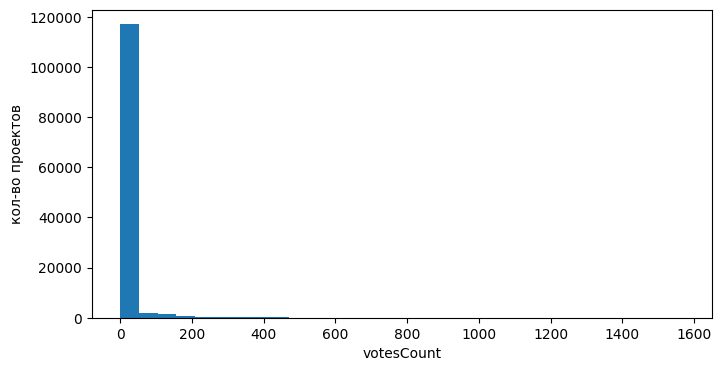

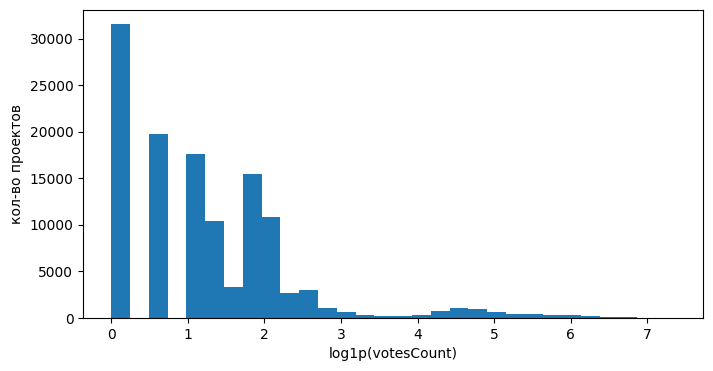

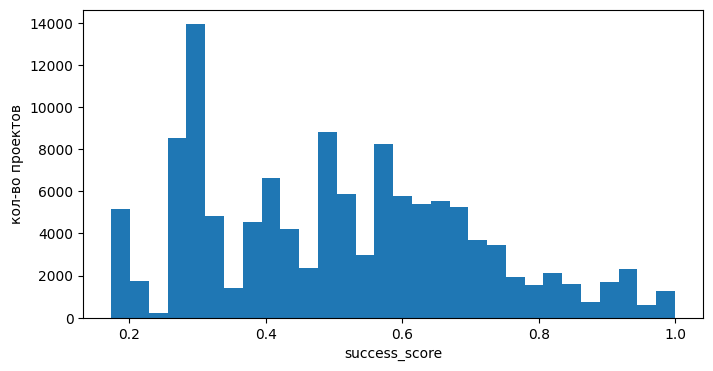

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(data["votesCount"].fillna(0), bins=30)
plt.xlabel("votesCount")
plt.ylabel("кол-во проектов")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(data["votesCount"].fillna(0)), bins=30)
plt.xlabel("log1p(votesCount)")
plt.ylabel("кол-во проектов")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(data["success_score"], bins=30)
plt.xlabel("success_score")
plt.ylabel("кол-во проектов")
plt.show()

Тут посмотрим на связи между отд. голосами и итоговым запуском

In [ ]:
outcome_columns = ["votesCount", "commentsCount", "reviewsCount", "collections_totalCount", "dailyRank", "weeklyRank", "monthlyRank", "success_score"]
outcome_columns = [col for col in outcome_columns if col in data.columns]

outcome_corr = data[outcome_columns].corr(method="spearman")[["success_score"]].sort_values("success_score", ascending=False)
outcome_corr

,success_score
success_score,1.000000
votesCount,0.965380
commentsCount,0.557467
collections_totalCount,0.381950
reviewsCount,0.231028
dailyRank,-0.752530
weeklyRank,-0.874230
monthlyRank,-0.920380


Сравним между собой успешные и неуспешные проекты, как и что они связаны между собй

In [ ]:
eda_group_table = data.groupby("successful_launch")[engineered_features].mean().T
eda_group_table.columns = ["not_successful", "successful"] if len(eda_group_table.columns) == 2 else eda_group_table.columns

if "successful" in eda_group_table.columns and "not_successful" in eda_group_table.columns:
    eda_group_table["difference"] = eda_group_table["successful"] - eda_group_table["not_successful"]
    eda_group_table["absolute_difference"] = eda_group_table["difference"].abs()
    eda_group_table = eda_group_table.sort_values("absolute_difference", ascending=False)

eda_group_table.head(20)

,not_successful,successful,difference,absolute_difference
user_followersCount,65.552833,4087.171300,4021.618467,4021.618467
user_account_age_days,298.094918,925.987508,627.892590,627.892590
user_submittedPosts_totalCount,3.713427,87.836987,84.123560,84.123560
user_followingCount,4.657784,81.420943,76.763159,76.763159
description_len,292.533369,269.920596,-22.612773,22.612773
description_words,44.601222,41.551623,-3.049599,3.049599
launch_month,4.999837,7.290304,2.290468,2.290468
name_len,14.721509,13.346030,-1.375479,1.375479
user_madePosts_totalCount,2.876739,4.164238,1.287498,1.287498
tagline_len,45.029221,45.311778,0.282557,0.282557


Вот теперь посмотрим на корреляцию признаков с успешностью запуска и дальше будем от этого плесать и брать только определенные столбцы

In [ ]:
correlation_data = data[engineered_features + ["success_score"]].copy()

for col in engineered_features:
    correlation_data[col] = pd.to_numeric(correlation_data[col], errors="coerce")

feature_correlations = correlation_data.corr(method="spearman")[["success_score"]].drop(index="success_score")
feature_correlations["abs_correlation"] = feature_correlations["success_score"].abs()
feature_correlations = feature_correlations.sort_values("abs_correlation", ascending=False)
feature_correlations.head(30)

,success_score,abs_correlation
user_followersCount,0.498482,0.498482
user_account_age_days,0.303315,0.303315
launch_month,0.286211,0.286211
user_followingCount,0.245264,0.245264
user_madePosts_totalCount,0.206033,0.206033
user_submittedPosts_totalCount,0.201560,0.201560
topics_totalCount,0.133274,0.133274
launch_hour,0.082701,0.082701
name_len,-0.078553,0.078553
name_words,-0.053156,0.053156


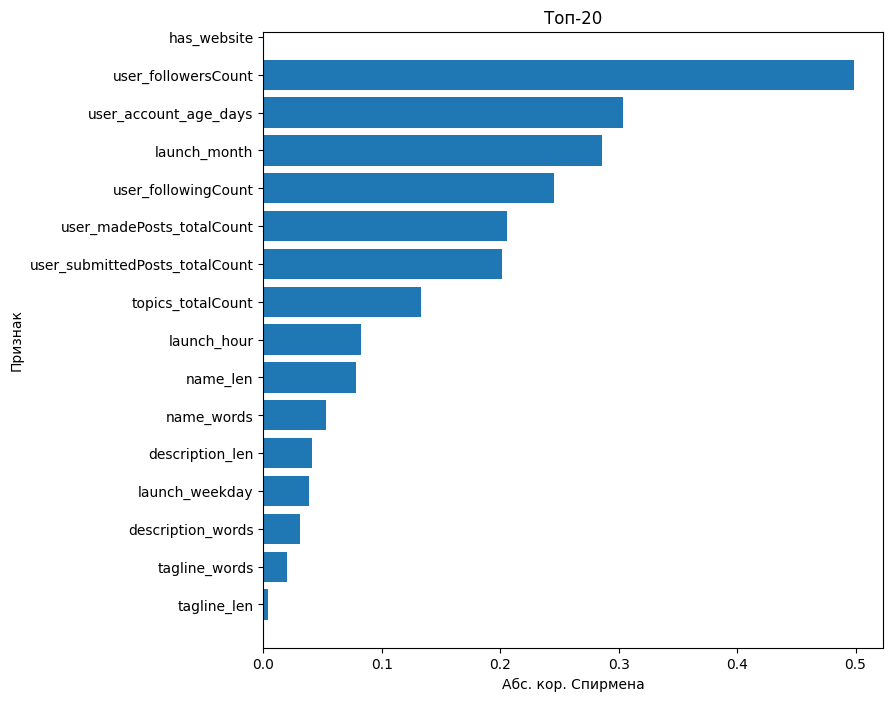

In [ ]:
plt.figure(figsize=(8, 8))
plot_data = feature_correlations.head(20).sort_values("abs_correlation")
plt.barh(plot_data.index, plot_data["abs_correlation"])
plt.title("Топ-20")
plt.xlabel("Абс. кор. Спирмена")
plt.ylabel("Признак")
plt.show()

Вот тут тоже думали, как и что оставить, решили взять признаки с корреляций не ниже 0,03

In [ ]:
MIN_TARGET_CORR = 0.03

selected_numeric_features = feature_correlations[
    feature_correlations["abs_correlation"] >= MIN_TARGET_CORR
].index.tolist()

selected_numeric_features = [
    col for col in selected_numeric_features
    if data[col].nunique(dropna=True) > 1
]

selected_numeric_features

['user_followersCount',
 'user_account_age_days',
 'launch_month',
 'user_followingCount',
 'user_madePosts_totalCount',
 'user_submittedPosts_totalCount',
 'topics_totalCount',
 'launch_hour',
 'name_len',
 'name_words',
 'description_len',
 'launch_weekday',
 'description_words']

И оставляем несколько категориальных признаков

In [ ]:
categorical_features = []

for col in ["primary_topic", "thumbnail_type"]:
    if col in data.columns and data[col].nunique(dropna=True) > 1:
        categorical_features.append(col)

print("Числовые признаки:")
print(selected_numeric_features)
print("Категориальные признаки:")
print(categorical_features)

Числовые признаки:
['user_followersCount', 'user_account_age_days', 'launch_month', 'user_followingCount', 'user_madePosts_totalCount', 'user_submittedPosts_totalCount', 'topics_totalCount', 'launch_hour', 'name_len', 'name_words', 'description_len', 'launch_weekday', 'description_words']
Категориальные признаки:
[]


Здесь подгатавливаем выборки

In [ ]:
model_columns = selected_numeric_features + categorical_features
model_data = data[model_columns + ["successful_launch", "success_score"]].copy()
model_data = model_data.dropna(subset=["successful_launch"])

X = model_data[model_columns]
y = model_data["successful_launch"].astype(int)

stratify_target = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_target
)

stratify_train = y_train_full if y_train_full.nunique() == 2 and y_train_full.value_counts().min() >= 2 else None

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=stratify_train
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).to_dict())
print("Valid:", X_valid.shape, y_valid.value_counts(normalize=True).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).to_dict())

Train: (78316, 13) {0: 0.7998237907962613, 1: 0.2001762092037387}
Valid: (19579, 13) {0: 0.7998365595791409, 1: 0.2001634404208591}
Test: (24474, 13) {0: 0.7998283893111057, 1: 0.20017161068889433}


тут выгрузка:


In [ ]:
from pathlib import Path

export_dir = Path("export_for_task_4")
export_dir.mkdir(exist_ok=True)

split_map = pd.Series(index=model_data.index, dtype="object")
split_map.loc[X_train.index] = "train"
split_map.loc[X_valid.index] = "valid"
split_map.loc[X_test.index] = "test"

dataset_for_task4 = data.loc[model_data.index].copy()
dataset_for_task4["split"] = split_map
dataset_for_task4["successful_launch"] = model_data["successful_launch"]
dataset_for_task4["success_score"] = model_data["success_score"]

dataset_for_task4.to_csv(export_dir / "product_hunt_processed_with_splits.csv", index=False)


Заполним числовые признаки и приведем к одному формату

In [ ]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_train_ready = preprocessor.fit_transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)
X_test_ready = preprocessor.transform(X_test)
X_all_ready = preprocessor.transform(X)

print(X_train_ready.shape)
print(X_valid_ready.shape)
print(X_test_ready.shape)

(78316, 13)
(19579, 13)
(24474, 13)


возьмем несколько метрик для сравнения в дальнейшем

In [ ]:
class_counts = y_train.value_counts().to_dict()
total_count = len(y_train)
class_weight = {}

for class_value, class_count in class_counts.items():
    class_weight[class_value] = total_count / (len(class_counts) * class_count)

class_weight

{0: 0.6251376937690576, 1: 2.4977993238502263}

Дальше сделаем функцию саму и метрики

In [ ]:
def build_dense_model(input_dim, hidden_layers, activation, dropout_rate, batch_norm, learning_rate):
    model = Sequential()
    for index, units in enumerate(hidden_layers):
        if index == 0:
            model.add(Dense(units, activation=activation, input_shape=(input_dim,)))
        else:
            model.add(Dense(units, activation=activation))
        if batch_norm:
            model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def calculate_metrics(model, X_part, y_part):
    probabilities = model.predict(X_part, verbose=0).reshape(-1)
    predictions = (probabilities >= 0.5).astype(int)
    result = {
        "accuracy": accuracy_score(y_part, predictions),
        "precision": precision_score(y_part, predictions, zero_division=0),
        "recall": recall_score(y_part, predictions, zero_division=0),
        "f1": f1_score(y_part, predictions, zero_division=0)
    }
    if len(np.unique(y_part)) == 2:
        result["roc_auc"] = roc_auc_score(y_part, probabilities)
    else:
        result["roc_auc"] = np.nan
    return result, probabilities, predictions

у нас 3 модели, зададим им настройку тут

In [72]:
model_configs = [
    {
        "name": "small_dense",
        "hidden_layers": [32],
        "activation": "relu",
        "dropout_rate": 0.0,
        "batch_norm": False,
        "learning_rate": 0.001,
        "epochs": 60,
        "batch_size": 64
    },
    {
        "name": "medium_dense",
        "hidden_layers": [64, 32],
        "activation": "relu",
        "dropout_rate": 0.10,
        "batch_norm": False,
        "learning_rate": 0.001,
        "epochs": 80,
        "batch_size": 64
    },
    {
        "name": "regularized_dense",
        "hidden_layers": [128, 64, 32],
        "activation": "relu",
        "dropout_rate": 0.25,
        "batch_norm": True,
        "learning_rate": 0.0007,
        "epochs": 100,
        "batch_size": 64
    }
]

Вот и основной блок, здесь у нас собственно обучение и логирование (MLflow возьмем)

In [71]:
mlflow.set_experiment("product_hunt_tabular_success")

results = []
trained_models = {}
artifacts_dir = Path("artifacts_tabular_success")
artifacts_dir.mkdir(exist_ok=True)

pd.DataFrame(X_train).assign(successful_launch=y_train.values).to_csv(artifacts_dir / "train_data.csv", index=False)
pd.DataFrame(X_valid).assign(successful_launch=y_valid.values).to_csv(artifacts_dir / "valid_data.csv", index=False)
pd.DataFrame(X_test).assign(successful_launch=y_test.values).to_csv(artifacts_dir / "test_data.csv", index=False)
joblib.dump(preprocessor, artifacts_dir / "preprocessor.joblib")

for config in model_configs:
    with mlflow.start_run(run_name=config["name"]):
        model = build_dense_model(
            input_dim=X_train_ready.shape[1],
            hidden_layers=config["hidden_layers"],
            activation=config["activation"],
            dropout_rate=config["dropout_rate"],
            batch_norm=config["batch_norm"],
            learning_rate=config["learning_rate"]
        )
        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
        history = model.fit(
            X_train_ready,
            y_train,
            validation_data=(X_valid_ready, y_valid),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            callbacks=[early_stopping],
            class_weight=class_weight,
            verbose=0
        )
        valid_metrics, valid_probabilities, valid_predictions = calculate_metrics(model, X_valid_ready, y_valid)
        test_metrics, test_probabilities, test_predictions = calculate_metrics(model, X_test_ready, y_test)
        mlflow.log_params({
            "hidden_layers": str(config["hidden_layers"]),
            "activation": config["activation"],
            "dropout_rate": config["dropout_rate"],
            "batch_norm": config["batch_norm"],
            "learning_rate": config["learning_rate"],
            "epochs_requested": config["epochs"],
            "epochs_finished": len(history.history["loss"]),
            "batch_size": config["batch_size"],
            "input_dim": X_train_ready.shape[1]
        })
        for metric_name, metric_value in valid_metrics.items():
            mlflow.log_metric("valid_" + metric_name, metric_value)
        for metric_name, metric_value in test_metrics.items():
            mlflow.log_metric("test_" + metric_name, metric_value)
        model_path = artifacts_dir / (config["name"] + ".keras")
        model.save(model_path)
        mlflow.log_artifact(str(model_path))
        mlflow.log_artifact(str(artifacts_dir / "preprocessor.joblib"))
        mlflow.log_artifact(str(artifacts_dir / "train_data.csv"))
        mlflow.log_artifact(str(artifacts_dir / "valid_data.csv"))
        mlflow.log_artifact(str(artifacts_dir / "test_data.csv"))
        result_row = {
            "model_name": config["name"],
            "epochs_finished": len(history.history["loss"])
        }
        for metric_name, metric_value in valid_metrics.items():
            result_row["valid_" + metric_name] = metric_value
        for metric_name, metric_value in test_metrics.items():
            result_row["test_" + metric_name] = metric_value
        results.append(result_row)
        trained_models[config["name"]] = model

results_df = pd.DataFrame(results)
results_df

2026/06/16 09:21:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/16 09:21:29 INFO mlflow.store.db.utils: Updating database tables
2026/06/16 09:21:35 INFO mlflow.tracking.fluent: Experiment with name 'product_hunt_tabular_success' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/di

,model_name,epochs_finished,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,small_dense,60,0.771132,0.457437,0.770605,0.574090,0.851131,0.771431,0.458057,0.774648,0.575698,0.853094
1,medium_dense,42,0.778283,0.467508,0.774687,0.583117,0.853148,0.779644,0.469438,0.774444,0.584547,0.855848
2,regularized_dense,41,0.790081,0.484703,0.772136,0.595552,0.864055,0.790267,0.485115,0.778322,0.597696,0.867866


Дальше финально посмотрим на матрицу ошибок

In [75]:
best_test_metrics, best_test_probabilities, best_test_predictions = calculate_metrics(best_model, X_test_ready, y_test)

print(best_test_metrics)
print(confusion_matrix(y_test, best_test_predictions))
print(classification_report(y_test, best_test_predictions, zero_division=0))

{'accuracy': 0.7902672223584212, 'precision': 0.4851145038167939, 'recall': 0.7783221065523577, 'f1': 0.5976957441805785, 'roc_auc': np.float64(0.867865999186114)}
[[15528  4047]
 [ 1086  3813]]
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     19575
           1       0.49      0.78      0.60      4899

    accuracy                           0.79     24474
   macro avg       0.71      0.79      0.73     24474
weighted avg       0.84      0.79      0.81     24474

